# Chapter 4: A Modern Architecture (GPT-2 → Llama-style) + a broader pretraining mix

In Chapter 3 you pretrained a ~50M base and SFT'd it into a (tiny) chat model. It *worked* — it answered in-template and stopped. But two things showed through the cracks:

- **It's knowledge-poor.** "Capital of France?" → "Germany". A 50M model that only ever read educational web text simply hasn't stored enough facts.
- **It's a 2019 design.** The `GPT`/`Block`/`CausalSelfAttention` you built is **GPT-2 architecture**. Every strong small model since (Llama, Qwen, Mistral, SmolLM2) changed the *same five things*. None of them are exotic — each is a small, well-motivated swap.

This chapter does two upgrades, then **A/B tests the result against `base.pt`**:

1. **Modern architecture** — rebuild the model into a **Llama-style** decoder.
2. **Broader data** — pretrain on a *mixture* of sources (general web + educational + code), not one corpus.

> **First, a myth to kill: we already have Flash Attention.** `F.scaled_dot_product_attention(is_causal=True)` (Ch.2–3) **already dispatches to the fused FlashAttention-2 kernel** on your Ada GPU — that's why attention never materializes the T×T matrix. So "add flash attention" is done. The new ground is everything *around* the attention: how positions are encoded, how the model normalizes, how the MLP is shaped, and how the K/V heads are organized.

### What's new vs Chapter 3 — and the one-line reason for each

| # | Component | GPT-2 (Ch.3) | Llama-style (Ch.4) | The benefit in one line |
|---|---|---|---|---|
| 1 | **Position** | learned absolute `wpe` table | **RoPE** (rotary) | encodes *relative* distance + extrapolates past the trained length, with **zero params** |
| 2 | **Normalization** | `LayerNorm` (mean+var, γ+β) | **RMSNorm** (var only, γ) | same stability, fewer ops, one fewer param tensor — measurably faster |
| 3 | **MLP** | `Linear→GELU→Linear` | **SwiGLU** (gated SiLU) | a learned multiplicative gate → better quality at equal params |
| 4 | **Attention heads** | MHA (8 Q + 8 KV) | **GQA** (8 Q + 2 KV) | shrinks the **KV cache** ~4× → much faster generation, ~no quality loss |
| 5 | **Biases** | on (every Linear) | **off** everywhere | norms already handle the shift; drop dead params, slightly steadier |
| + | **Generation** | recompute the whole prefix every token | **KV cache** | turns O(T²) decoding into O(T) — and is *why* GQA matters |

### The main takeaway (read this before the details)

None of these make the model "smarter" by magic. They each remove a specific inefficiency in the **2019** design:
- RoPE removes a *length ceiling* and a parameter table by making position **relative and free**.
- RMSNorm removes a redundant *centering* step (the mean-subtraction turns out not to matter).
- SwiGLU spends the MLP's parameter budget on a *gate* (an input-dependent on/off valve) instead of a flat nonlinearity.
- GQA removes *redundant KV heads* — the part of attention that dominates **inference** memory/bandwidth.
- Dropping biases removes parameters a normalized network doesn't need.

The sum is a model that trains a little faster, generates a lot faster, generalizes to longer inputs, and squeezes more quality from the same ~50M params. Then the **data mixture** attacks the knowledge gap directly. We finish by generating from the new model and the old `base.pt` side by side.

**Pattern unchanged:** each new component = concept (what/why/benefit) → `TODO` stub you implement → a `# check` cell that fails loudly if it's wrong. Training scaffolding (data caches, the instrumented loop) is reproduced *given* — you built it in 3a.

## 0. Setup + the new `Config`

Same imports as 3a. The `Config` grows a few fields the modern architecture needs. The two genuinely new ones:

- **`n_kv_heads`** — how many *key/value* heads (GQA). With `n_heads=8, n_kv_heads=2`, every 4 query heads share one KV head. `n_kv_heads == n_heads` would be plain MHA; `n_kv_heads == 1` would be MQA.
- **`rope_theta`** — the base frequency for RoPE (10000 is the Llama default; larger → slower rotation → longer effective context).

`d_ff` is set to **1408 ≈ 8/3 · d_model** (not 4 · d_model). SwiGLU uses *three* weight matrices instead of two, so we shrink the hidden width to ~2/3 to keep the MLP's parameter count the same as Ch.3 — that's why "8/3" shows up everywhere in Llama configs. (`4 · 2/3 = 8/3`.)

In [1]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import tiktoken
import torch
import torch.nn.functional as F
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token
VOCAB_SIZE = enc.n_vocab


@dataclass
class Config:
    vocab_size: int = VOCAB_SIZE
    d_model: int = 512
    n_heads: int = 8
    n_kv_heads: int = 2        # GQA: 8 query heads share 2 KV heads (4:1). ==n_heads -> MHA; ==1 -> MQA
    d_ff: int = 1408           # ~ 8/3 * d_model, rounded to a multiple of 64 (SwiGLU has 3 matrices)
    n_layers: int = 8
    block_size: int = 256      # same as Ch.3 for a clean A/B (RoPE *lets* us go longer -- a knob, not used here)
    rope_theta: float = 10000.0
    dropout: float = 0.0

    def __post_init__(self):
        assert self.d_model % self.n_heads == 0, "d_model must divide into heads"
        assert self.n_heads % self.n_kv_heads == 0, "n_heads must be a multiple of n_kv_heads (GQA grouping)"


cfg = Config()
print(cfg)
print(f"head dim d_k = {cfg.d_model // cfg.n_heads}, query:kv group size = {cfg.n_heads // cfg.n_kv_heads}:1")

device: cuda
gpu: NVIDIA GeForce RTX 4060 Ti
Config(vocab_size=50257, d_model=512, n_heads=8, n_kv_heads=2, d_ff=1408, n_layers=8, block_size=256, rope_theta=10000.0, dropout=0.0)
head dim d_k = 64, query:kv group size = 4:1


## 1. RoPE — Rotary Position Embeddings

### The problem with learned absolute positions (Ch.2–3)

In Ch.3 the model added a learned vector `wpe[pos]` to each token embedding. Three downsides:

1. **Hard length ceiling.** There are exactly `block_size` rows in `wpe`. Feed position 257 to a 256-trained model and there is *no vector* for it — it cannot run on longer text than it trained on.
2. **It encodes *absolute* position.** But attention fundamentally cares about *relative* position — "the token 3 back", "the previous word" — not "the 145th token". Absolute embeddings make the model *learn* relativity the hard way.
3. **It costs parameters** (`block_size × d_model`) that do nothing but index position.

### The RoPE idea: rotate, don't add

RoPE adds **nothing** to the embeddings. Instead, inside attention, it **rotates** each query and key vector by an angle proportional to its position. Take a 2-D slice `(a, b)` of a head vector at position `m`; rotate it by angle `m·θ`:

```
[a']   [cos mθ  -sin mθ] [a]
[b'] = [sin mθ   cos mθ] [b]
```

The magic: when you later take the dot product of a **query** rotated by `m·θ` and a **key** rotated by `n·θ`, the result depends only on the **difference `m − n`** (rotations compose: rotate by m then "un-rotate" by n leaves m−n). So:

- the attention score between two tokens automatically depends on their **relative distance**, not their absolute positions;
- it **extrapolates**: nothing is indexed by a fixed table, so positions beyond the trained length still rotate sensibly;
- it is **parameter-free**: `cos`/`sin` are *computed*, not learned.

### Mechanics

We split the `d_k`-dim head vector into `d_k/2` pairs. Pair `j` rotates at its own frequency `θ^(−2j/d_k)`: low pairs spin slowly (capture long-range position), high pairs spin fast (capture local position) — the same multi-scale idea as the old sinusoidal encoding, but applied as a **rotation of q and k** rather than an additive signal. The efficient implementation precomputes `cos`/`sin` of shape `(max_pos, d_k)` and uses the `rotate_half` trick (rotate the two halves of the vector against each other) instead of looping over pairs.

| variable | shape | meaning |
|---|---|---|
| `inv_freq` | `(d_k/2,)` | per-pair angular frequency `θ^(−2j/d_k)` |
| `cos`, `sin` | `(max_pos, d_k)` | precomputed rotation table for every position |
| `q`, `k` | `(B, H, T, d_k)` | per-head query/key; RoPE rotates each in place |

**Benefit recap:** relative-by-construction, length-extrapolating, zero params. This is why every modern open LLM (Llama 1/2/3, Qwen, Mistral, SmolLM2) uses RoPE.

In [2]:
def precompute_rope(d_k, max_pos, theta=10000.0, device="cpu"):
    """Return (cos, sin), each (max_pos, d_k), the rotation tables for RoPE.

    Steps:
      1. inv_freq = 1.0 / (theta ** (arange(0, d_k, 2)/d_k))      # (d_k/2,) per-pair frequency
      2. t = arange(max_pos)                                       # (max_pos,) positions
      3. freqs = outer(t, inv_freq)                                # (max_pos, d_k/2) angle per (pos, pair)
      4. emb = cat([freqs, freqs], dim=-1)                         # (max_pos, d_k)  duplicate for the two halves
      5. return emb.cos(), emb.sin()
    """
    inv_freq = 1.0 / (theta ** (torch.arange(0, d_k, 2, device=device) / d_k))  # (d_k/2,) per-pair frequency
    t = torch.arange(max_pos, device=device)  # (max_pos,) positions
    freqs = torch.outer(t, inv_freq)
    emb = torch.cat([freqs, freqs], dim=-1)  # (max_pos, d_k)  duplicate for the two halves
    return emb.cos(), emb.sin()  # (max_pos, d_k), (max

def rotate_half(x):
    """(..., d_k) -> rotate the two halves against each other: [-x2, x1]. (the 'rotate_half' trick)"""
    # TODO: x1 = first half, x2 = second half; return cat([-x2, x1], dim=-1)
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(q, k, cos, sin):
    """Rotate q,k by RoPE. q,k: (B,H,T,d_k). cos,sin: (T,d_k) for the current positions.

    q_rot = q*cos + rotate_half(q)*sin   (broadcast cos/sin over batch & heads)
    """
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot

In [3]:
# check -- RoPE must (a) preserve vector norm (pure rotation) and (b) be RELATIVE:
# the q.k score for a fixed offset must be identical regardless of absolute position.
torch.manual_seed(0)
_dk, _T = 64, 16
_cos, _sin = precompute_rope(_dk, _T, theta=10000.0)
assert _cos.shape == (_T, _dk) and _sin.shape == (_T, _dk), "rope table wrong shape"

_q = torch.randn(1, 1, _T, _dk)
_k = torch.randn(1, 1, _T, _dk)
_qr, _kr = apply_rope(_q, _k, _cos, _sin)
# (a) rotation preserves norm
assert torch.allclose(_q.norm(dim=-1), _qr.norm(dim=-1), atol=1e-4), "RoPE must preserve norm (it's a rotation)"

# (b) relative property: put the SAME vector v at every position; score(pos_i, pos_j) should depend only on i-j
_v = torch.randn(1, 1, 1, _dk).expand(1, 1, _T, _dk).contiguous()
_vr, _ = apply_rope(_v, _v, _cos, _sin)
_scores = (_vr[0, 0] @ _vr[0, 0].T)            # (T, T) all-pairs dot product
# diagonals of constant offset must be (nearly) constant
for off in [1, 3, 7]:
    d = torch.diagonal(_scores, offset=off)
    assert (d.max() - d.min()) < 1e-3, f"offset {off} score not constant -> RoPE isn't purely relative"
print("ok: RoPE preserves norm and encodes purely relative position")

ok: RoPE preserves norm and encodes purely relative position


## 2. RMSNorm — normalize by scale only

### LayerNorm, and the part that turns out to be dead weight

`LayerNorm` does two things to each vector `x`:
1. **re-center**: subtract the mean → zero-mean;
2. **re-scale**: divide by the standard deviation → unit-variance;
then applies a learned **gain γ** and **bias β**.

The 2019 finding baked into Llama: the **re-centering (and the bias) barely matter**. What actually stabilizes a deep residual stream is keeping the *scale* of activations under control. RMSNorm keeps only that:

```
RMSNorm(x) = x / sqrt(mean(x²) + eps) · γ
```

No mean subtraction, no β. (`mean(x²)` is the mean *square*; its square root is the root-mean-square — the "RMS".)

### Why this is a real win, not just minimalism

- **Fewer ops:** no mean, no subtract — just one reduction (`x²` mean) and a multiply. On a memory-bandwidth-bound op repeated `2·n_layers+1` times per forward, that's measurable.
- **One fewer parameter tensor** (no β) and no centering means it's **numerically simpler** and plays nicer with low precision.
- **It just works:** Llama, Qwen, Mistral, T5, Gemma all use RMSNorm; the quality is equal to LayerNorm at lower cost.

| variable | shape | meaning |
|---|---|---|
| `x` | `(..., d)` | the vector(s) to normalize (last dim is the feature dim) |
| `weight` (γ) | `(d,)` | learned per-feature gain, initialized to 1 |
| `eps` | scalar | tiny constant so we never divide by 0 |

In [4]:
class RMSNorm(nn.Module):
    """RMSNorm: x / sqrt(mean(x^2) + eps) * weight.  No mean-subtraction, no bias."""
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d))   # gamma, starts at 1

    def forward(self, x):
        # TODO:
        # 1. compute rms = sqrt(mean(x^2, last dim, keepdim=True) + eps)
        # 2. return x / rms * self.weight
        # (compute the mean in float32 for stability even under autocast: x.float() then cast back)
        rms = torch.sqrt(torch.mean(x.float() ** 2, dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight


In [5]:
# check -- after RMSNorm (gamma=1) the per-vector RMS must be ~1, and it must NOT zero the mean
_n = RMSNorm(32)
_x = torch.randn(4, 10, 32) * 3.0 + 5.0           # non-zero mean, large scale
_y = _n(_x)
_rms = _y.pow(2).mean(-1).sqrt()
assert torch.allclose(_rms, torch.ones_like(_rms), atol=1e-2), "RMSNorm output should have RMS ~ 1"
# unlike LayerNorm, the mean is NOT forced to 0 (we only rescale)
assert _y.mean(-1).abs().mean() > 1e-3, "RMSNorm should NOT re-center (that's the whole point vs LayerNorm)"
print("ok: RMSNorm rescales to unit RMS without re-centering")

ok: RMSNorm rescales to unit RMS without re-centering


## 3. SwiGLU — a gated MLP

### The GPT-2 MLP vs a gated MLP

Ch.3's block had the standard MLP: `down(GELU(up(x)))` — project up to `d_ff`, apply a fixed nonlinearity, project back. Two weight matrices.

**SwiGLU** replaces the single nonlinearity with a **gate**:

```
SwiGLU(x) = down( SiLU(gate(x)) ⊙ up(x) )
```

- `gate(x)` and `up(x)` are **two separate** up-projections (`d_model → d_ff`).
- `SiLU(z) = z·sigmoid(z)` (a smooth, GELU-like activation).
- `⊙` is elementwise multiply — the SiLU'd gate branch acts as a **per-feature, input-dependent valve** on the up branch: where the gate is ~0 it shuts that feature off, where it's ~1 it passes through.
- `down` projects `d_ff → d_model`.

### Why a gate beats a flat nonlinearity

A plain `GELU(up(x))` applies the *same* curve to every feature. A gate lets the network decide, **per input**, how much each hidden feature should contribute — a multiplicative interaction the plain MLP can't represent without extra depth. Empirically (Shazeer, *"GLU Variants Improve Transformer"*) GLU-family MLPs consistently lower loss at **equal parameter count**, which is why Llama/PaLM/Mistral/Qwen all use SwiGLU.

### The "8/3" bookkeeping

SwiGLU uses **three** matrices (`gate`, `up`, `down`) vs the plain MLP's two. To keep the parameter count identical to a `4·d_model` plain MLP, shrink the hidden width to `8/3·d_model` (`= 4 · 2/3`). That's exactly our `d_ff = 1408 ≈ 8/3·512`. So this is a *free* swap, parameter-for-parameter — you spend the same budget, but on a gate.

| matrix | shape | role |
|---|---|---|
| `gate` (`w1`) | `d_model → d_ff` | the branch that gets SiLU'd into a valve |
| `up` (`w3`) | `d_model → d_ff` | the branch the valve multiplies |
| `down` (`w2`) | `d_ff → d_model` | project back to the residual stream |

In [6]:
class SwiGLU(nn.Module):
    """SwiGLU MLP: down( SiLU(gate(x)) * up(x) ).  Three Linears, all bias-free."""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.gate = nn.Linear(d_model, d_ff, bias=False)   # w1
        self.up   = nn.Linear(d_model, d_ff, bias=False)   # w3
        self.down = nn.Linear(d_ff, d_model, bias=False)   # w2
        self.down.RESIDUAL_SCALE_INIT = True               # writes back into the residual stream (see init)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


In [7]:
# check -- shape preserved, and param count matches an equivalent plain MLP at d_ff_plain = 4*d_model
_m = SwiGLU(cfg.d_model, cfg.d_ff)
_out = _m(torch.randn(2, 5, cfg.d_model))
assert _out.shape == (2, 5, cfg.d_model), "SwiGLU must preserve (B,T,d_model)"
_swiglu_params = sum(p.numel() for p in _m.parameters())
_plain_params = 2 * cfg.d_model * (4 * cfg.d_model)        # up(d->4d) + down(4d->d), no bias
print(f"SwiGLU params @ d_ff={cfg.d_ff}: {_swiglu_params:,}   vs plain MLP @ 4*d_model: {_plain_params:,}")
assert abs(_swiglu_params - _plain_params) / _plain_params < 0.10, "8/3 sizing should keep params ~equal"
print("ok: SwiGLU preserves shape and ~matches a plain MLP's param budget (the 8/3 trick)")

SwiGLU params @ d_ff=1408: 2,162,688   vs plain MLP @ 4*d_model: 2,097,152
ok: SwiGLU preserves shape and ~matches a plain MLP's param budget (the 8/3 trick)


## 4. GQA — Grouped-Query Attention

### MHA → MQA → GQA

In Ch.3's attention, the `qkv` projection produced **8 query heads, 8 key heads, 8 value heads** — every query head had its *own* K and V. That's **Multi-Head Attention (MHA)**.

The observation behind GQA: at **inference**, you cache K and V for every past token (the "KV cache", §6). With MHA that cache is `2 · n_layers · n_heads · d_k` per token — and reading it back each step is the **bandwidth bottleneck** of generation. The query heads are cheap; the *KV heads* are what hurt.

- **MQA (Multi-Query Attention):** all query heads share **one** K/V head. Cache shrinks `n_heads×` → very fast, but a measurable quality drop (one KV head is a tight bottleneck).
- **GQA (Grouped-Query Attention):** the middle ground. Use a few KV heads (here **2**); each is shared by a *group* of query heads (here 4). You get most of MQA's cache savings (`n_heads / n_kv_heads = 4×` smaller) with ~none of the quality loss.

```
MHA (8 KV)            GQA (2 KV, our config)        MQA (1 KV)
Q0 Q1 .. Q7           Q0 Q1 Q2 Q3 | Q4 Q5 Q6 Q7      Q0..Q7
K0 K1 .. K7           K0 (shared)  | K1 (shared)      K0 (shared)
V0 V1 .. V7           V0           | V1               V0
```

Llama-2-70B, Llama-3 (all sizes), Mistral, Qwen2 all use GQA. It is the standard for anything that has to generate quickly.

### Mechanics (what the TODO does)

1. Project `x` to `q` (`n_heads·d_k`), `k`,`v` (`n_kv_heads·d_k`) — note k,v are **narrower**. All bias-free.
2. Reshape: `q → (B, n_heads, T, d_k)`, `k,v → (B, n_kv_heads, T, d_k)`.
3. **Apply RoPE** to `q` and `k` (positions enter here, §1).
4. **`repeat_kv`**: expand the `n_kv_heads` K/V up to `n_heads` by repeating each KV head for its group, so SDPA sees matching head counts.
5. `F.scaled_dot_product_attention(..., is_causal=...)` — the fused FlashAttention kernel.
6. Merge heads, `o_proj` back to `d_model`.

The same `forward` also supports a **KV cache** (`past_kv`) for §6: if given, concatenate past K/V before attending, and return the updated K/V.

| variable | shape | meaning |
|---|---|---|
| `q` | `(B, n_heads, T, d_k)` | one query per head |
| `k`,`v` (pre-repeat) | `(B, n_kv_heads, T, d_k)` | shared across query groups |
| `k`,`v` (post-`repeat_kv`) | `(B, n_heads, T, d_k)` | expanded so SDPA head counts match |

In [8]:
def repeat_kv(x, n_rep):
    """(B, n_kv, T, d_k) -> (B, n_kv*n_rep, T, d_k) by repeating each KV head n_rep times (contiguously)."""
    if n_rep == 1:
        return x
    b, n_kv, t, d = x.shape
    return (x[:, :, None, :, :]                       # (B, n_kv, 1, T, d)
            .expand(b, n_kv, n_rep, t, d)             # (B, n_kv, n_rep, T, d)
            .reshape(b, n_kv * n_rep, t, d))          # (B, n_kv*n_rep, T, d)


class GroupedQueryAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.n_kv = cfg.n_kv_heads
        self.n_rep = cfg.n_heads // cfg.n_kv_heads
        self.d_k = cfg.d_model // cfg.n_heads
        self.q_proj = nn.Linear(cfg.d_model, cfg.n_heads * self.d_k, bias=False)
        self.k_proj = nn.Linear(cfg.d_model, cfg.n_kv_heads * self.d_k, bias=False)
        self.v_proj = nn.Linear(cfg.d_model, cfg.n_kv_heads * self.d_k, bias=False)
        self.o_proj = nn.Linear(cfg.n_heads * self.d_k, cfg.d_model, bias=False)
        self.o_proj.RESIDUAL_SCALE_INIT = True
        self.dropout = cfg.dropout

    def forward(self, x, cos, sin, past_kv=None, use_cache=False, is_causal=True):
        """x:(B,T,d). cos,sin:(T,d_k) for THIS chunk's positions. Returns (out, present_kv)."""
        B, T, _ = x.shape
        # TODO:
        # 1. q = q_proj(x).view(B, T, n_heads, d_k).transpose(1,2)      -> (B, n_heads, T, d_k)
        #    k = k_proj(x).view(B, T, n_kv,    d_k).transpose(1,2)      -> (B, n_kv,    T, d_k)
        #    v = v_proj(x).view(B, T, n_kv,    d_k).transpose(1,2)      -> (B, n_kv,    T, d_k)
        # 2. q, k = apply_rope(q, k, cos, sin)                          # positions enter here
        # 3. if past_kv is not None: k = cat([past_kv[0], k], dim=2); v = cat([past_kv[1], v], dim=2)
        #    present = (k, v) if use_cache else None
        # 4. k = repeat_kv(k, n_rep); v = repeat_kv(v, n_rep)          # expand KV up to n_heads
        # 5. out = F.scaled_dot_product_attention(q, k, v, is_causal=is_causal,
        #             dropout_p=self.dropout if self.training else 0.0)
        # 6. out = out.transpose(1,2).reshape(B, T, -1); return self.o_proj(out), present
        q = self.q_proj(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, n_heads, T, d_k)
        k = self.k_proj(x).view(B, T, self.n_kv, self.d_k).transpose(1, 2)  # (B, n_kv, T, d_k)
        v = self.v_proj(x).view(B, T, self.n_kv, self.d_k).transpose(1, 2)  # (B, n_kv, T, d_k)
        q, k = apply_rope(q, k, cos, sin)  # positions enter here
        if past_kv is not None:
            k = torch.cat([past_kv[0], k], dim=2)
            v = torch.cat([past_kv[1], v], dim=2)
        present = (k, v) if use_cache else None
        k = repeat_kv(k, self.n_rep)
        v = repeat_kv(v, self.n_rep)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=is_causal, dropout_p=self.dropout if self.training else 0.0)
        out = out.transpose(1, 2).reshape(B, T, -1)
        return self.o_proj(out), present    

In [9]:
# check -- shapes, GQA grouping, and causal correctness vs a manual masked-softmax reference
_attn = GroupedQueryAttention(cfg)
_cos, _sin = precompute_rope(cfg.d_model // cfg.n_heads, cfg.block_size, cfg.rope_theta)
_x = torch.randn(2, 7, cfg.d_model)
_out, _present = _attn(_x, _cos[:7], _sin[:7], use_cache=True)
assert _out.shape == (2, 7, cfg.d_model), "attention output shape wrong"
assert _present[0].shape == (2, cfg.n_kv_heads, 7, cfg.d_model // cfg.n_heads), "cached K must have n_kv heads"
# KV projections must be NARROWER than Q (that's the whole memory win)
assert _attn.k_proj.weight.shape[0] < _attn.q_proj.weight.shape[0], "GQA: K/V projections must be smaller than Q"
print(f"ok: GQA output {tuple(_out.shape)}, KV-cache heads = {cfg.n_kv_heads} (vs {cfg.n_heads} query heads)")
print(f"    KV cache is {cfg.n_heads // cfg.n_kv_heads}x smaller than MHA would be")

ok: GQA output (2, 7, 512), KV-cache heads = 2 (vs 8 query heads)
    KV cache is 4x smaller than MHA would be


## 5. Assemble the Llama-style block and model (given)

Now we stack the four pieces into the modern decoder. Compared to Ch.3's `Block`/`GPT`, the diffs are exactly our five changes — read them off the code:

- **pre-norm with `RMSNorm`** (was `LayerNorm`), `x = x + attn(norm(x))`, `x = x + mlp(norm(x))` — the residual pattern itself is unchanged (you learned it in Ch.2).
- `attn` is **GQA + RoPE**; `mlp` is **SwiGLU**.
- **no `wpe`** — position comes from RoPE inside attention, so the model only has the token embedding `wte`.
- **no biases** anywhere (all Linears `bias=False`); RMSNorm has no bias either.
- **weight tying** (`lm_head.weight = wte.weight`) and the **residual-scale init** (`1/sqrt(2·n_layers)` on the two projections that write into the residual stream) **carry over from Ch.2** — they matter just as much here.

RoPE's `cos`/`sin` tables are stored as **buffers** (computed once, not learned, moved with `.to(device)`), sliced to the current sequence length each forward.

In [ ]:
class LlamaBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn_norm = RMSNorm(cfg.d_model)
        self.attn = GroupedQueryAttention(cfg)
        self.mlp_norm = RMSNorm(cfg.d_model)
        self.mlp = SwiGLU(cfg.d_model, cfg.d_ff)

    def forward(self, x, cos, sin, past_kv=None, use_cache=False, is_causal=True):
        a, present = self.attn(self.attn_norm(x), cos, sin, past_kv, use_cache, is_causal)
        x = x + a
        x = x + self.mlp(self.mlp_norm(x))
        return x, present


class LlamaGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.block_size = cfg.block_size
        self.n_layers = cfg.n_layers
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)     # NO wpe -- RoPE handles position
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([LlamaBlock(cfg) for _ in range(cfg.n_layers)])
        self.norm_f = RMSNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight                    # weight tying (Ch.2)

        # RoPE tables as buffers (computed once, not parameters)
        d_k = cfg.d_model // cfg.n_heads
        cos, sin = precompute_rope(d_k, cfg.block_size, cfg.rope_theta)
        self.register_buffer("rope_cos", cos, persistent=False)
        self.register_buffer("rope_sin", sin, persistent=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if getattr(module, "RESIDUAL_SCALE_INIT", False):   # Ch.2 fix: scale residual writers by 1/sqrt(2L)
                std /= math.sqrt(2 * self.n_layers)
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        cos, sin = self.rope_cos[:T], self.rope_sin[:T]
        x = self.drop(self.wte(idx))                            # just the token embedding
        for block in self.blocks:
            x, _ = block(x, cos, sin, is_causal=True)
        x = self.norm_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
        return logits, loss

In [ ]:
# check -- builds, ~50M params (comparable to Ch.3 base), first loss ~ ln(V)
_model = LlamaGPT(cfg).to(device)
_n = sum(p.numel() for p in _model.parameters())
print(f"params: {_n/1e6:.1f}M   (Ch.3 base was 51.1M -- modern arch keeps it comparable for the A/B)")
_idx = torch.randint(0, VOCAB_SIZE, (2, cfg.block_size), device=device)
_tgt = torch.randint(0, VOCAB_SIZE, (2, cfg.block_size), device=device)   # independent targets -> loss ~ ln(V)
with torch.autocast(device_type=device, dtype=torch.bfloat16):
    _logits, _loss = _model(_idx, _tgt)
print(f"logits {tuple(_logits.shape)}, first loss {_loss.item():.3f}  (sanity ln(V) = {math.log(VOCAB_SIZE):.3f})")
assert _logits.shape == (2, cfg.block_size, VOCAB_SIZE), "logits shape wrong"
assert 9.5 < _loss.item() < 12.0, "fresh-init loss should sit near ln(V)~10.8 -- init/arch bug"
print("ok: Llama-style model builds, sized right, loss near ln(V) on random init")
del _model

## 6. KV-cache generation — why GQA was worth it

### The waste in naive generation

In 3a/3b, every new token re-ran the **whole** prefix through the model: to produce token 100 you recomputed the attention over tokens 1–99 from scratch. Generating `N` tokens costs **O(N²)** — the slow, serial sampling you watched.

But the K and V for tokens 1–99 **don't change** when you add token 100. So cache them. With a **KV cache**:

1. **Prefill:** run the prompt once, store each layer's `(K, V)`.
2. **Per step:** feed only the *one* new token, compute its `q,k,v`, **append** its `k,v` to the cache, attend over the whole cache. O(1) work per token → **O(N)** total.

### This is the whole point of GQA

The cache size is `2 · n_layers · n_kv_heads · d_k · seq_len · dtype_bytes`. It scales with **`n_kv_heads`** — which GQA cut from 8 to 2. So GQA makes the cache **4× smaller** and the per-step memory reads **4× cheaper**, which is most of what generation speed is bound by. Architecture choice (§4) and inference speed (here) are the same decision.

The `generate` below threads `past_kv` through every block. Note the masking subtlety: the **prefill** chunk is `is_causal=True` (a real token grid), but each **single new token** attends to *all* cached positions and has no future to mask, so it uses `is_causal=False`.

In [ ]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=0.8, top_k=50):
    """KV-cached autoregressive generation. idx: (1, P). Returns (1, P+new)."""
    model.eval()
    d_k = model.cfg.d_model // model.cfg.n_heads
    caches = [None] * len(model.blocks)

    def step(tokens, start_pos, is_causal):
        T = tokens.shape[1]
        cos = model.rope_cos[start_pos:start_pos + T]      # positions for THIS chunk
        sin = model.rope_sin[start_pos:start_pos + T]
        x = model.wte(tokens)
        for i, block in enumerate(model.blocks):
            x, caches[i] = block(x, cos, sin, past_kv=caches[i], use_cache=True, is_causal=is_causal)
        return model.lm_head(model.norm_f(x))[:, -1, :]    # last-position logits

    # prefill the prompt (causal), then decode one token at a time (cache grows)
    pos = idx.shape[1]
    logits = step(idx, 0, is_causal=True)
    for _ in range(max_new_tokens):
        logits = logits / temperature
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float("-inf")
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt], dim=1)
        if nxt.item() == EOT:
            break
        logits = step(nxt, pos, is_causal=False)           # one new token attends to the whole cache
        pos += 1
    model.train()
    return idx


def complete(model, prompt, max_new_tokens=60, temperature=0.7, top_k=50):
    ids = torch.tensor([enc.encode_ordinary(prompt)], device=device)
    return enc.decode(generate(model, ids, max_new_tokens, temperature, top_k)[0].tolist())

In [ ]:
# check -- cached generation must match a brute-force uncached forward at every step (greedy)
torch.manual_seed(0)
_m = LlamaGPT(cfg).to(device).eval()
_prompt = torch.randint(0, VOCAB_SIZE, (1, 5), device=device)

# greedy with cache
@torch.no_grad()
def _greedy_cached(model, idx, n):
    d_k = model.cfg.d_model // model.cfg.n_heads
    caches = [None] * len(model.blocks)
    def step(tok, start, causal):
        T = tok.shape[1]; cos = model.rope_cos[start:start+T]; sin = model.rope_sin[start:start+T]
        x = model.wte(tok)
        for i, b in enumerate(model.blocks):
            x, caches[i] = b(x, cos, sin, past_kv=caches[i], use_cache=True, is_causal=causal)
        return model.lm_head(model.norm_f(x))[:, -1, :]
    pos = idx.shape[1]; lg = step(idx, 0, True); out = idx
    for _ in range(n):
        nxt = lg.argmax(-1, keepdim=True); out = torch.cat([out, nxt], 1)
        lg = step(nxt, pos, False); pos += 1
    return out

# greedy without cache (recompute full context each step)
@torch.no_grad()
def _greedy_full(model, idx, n):
    out = idx
    for _ in range(n):
        lg, _ = model(out)
        nxt = lg[:, -1, :].argmax(-1, keepdim=True)
        out = torch.cat([out, nxt], 1)
    return out

_a = _greedy_cached(_m, _prompt, 12)
_b = _greedy_full(_m, _prompt, 12)
assert torch.equal(_a, _b), "KV-cached generation diverged from the uncached forward -- cache/masking bug"
print("ok: KV-cached generation is identical to the uncached forward (and O(N) not O(N^2))")
del _m

## 7. A broader pretraining mix — coverage by mixing sources

### Why a mixture

The Ch.3 base read **only** FineWeb-Edu. That's clean, but narrow — it explains the knowledge gaps. Real pretraining corpora are **mixtures**: general web for breadth, curated/educational for quality, code for structure and step-by-step reasoning. We sample each batch from a randomly chosen source according to a **weight**:

| source | dataset | why it's in the mix | weight |
|---|---|---|---|
| general web | `HuggingFaceFW/fineweb` (`sample-10BT`) | broad facts & registers the edu set misses | 0.45 |
| educational | `HuggingFaceFW/fineweb-edu` (`sample-10BT`) | clean, high-signal explanatory text | 0.35 |
| code | `bigcode/the-stack-smol` | structure, logic, long-range consistency | 0.20 |

Each source is tokenized to its **own** uint16 `.bin` (same machinery as 3a). A `mixture_get_batch` then (1) picks a source by weight, (2) draws a random window from that source's memmap. Over many steps the model sees roughly `weight`-proportioned tokens from each.

> **This is also the multilingual on-ramp.** Swap the sources for per-language slices (`fra_Latn`, `deu_Latn`, …) of FineWeb-2/MADLAD and the *exact same* weighted-mixture loader gives you a multilingual base. Nothing else changes.

> **ponytail:** the per-source caches + a weighted draw are the whole idea. We are NOT building a token-accurate global shuffle or a streaming interleave — for a from-scratch learning run, per-batch source sampling is plenty and is one function. Default budgets are small; bump them for a real run.

In [ ]:
from datasets import load_dataset


def build_cache(path, repo, token_budget, config=None, split="train", text_field="text"):
    """Generalized 3a token cache: stream `repo`, tokenize `text_field`, write uint16 .bin. Skips if it exists."""
    if os.path.exists(path):
        print(f"{path} exists ({os.path.getsize(path)//2:,} tokens) -- skip")
        return path
    ds = load_dataset(repo, name=config, split=split, streaming=True)
    arr = np.memmap(path, dtype=np.uint16, mode="w+", shape=(token_budget,))
    written, t0 = 0, time.time()
    for doc in ds:
        text = doc.get(text_field) or ""
        if not text:
            continue
        ids = enc.encode_ordinary(text) + [EOT]
        take = ids[: token_budget - written]
        arr[written:written + len(take)] = take
        written += len(take)
        if written >= token_budget:
            break
    arr.flush()
    print(f"done: {written:,} tokens -> {path} ({time.time()-t0:.0f}s)")
    return path


# (repo, config, text_field, weight, per-source token budget). Small defaults -- raise for a real run.
SOURCES = [
    {"name": "web",  "repo": "HuggingFaceFW/fineweb",     "config": "sample-10BT", "text_field": "text",    "weight": 0.45, "budget": 120_000_000},
    {"name": "edu",  "repo": "HuggingFaceFW/fineweb-edu", "config": "sample-10BT", "text_field": "text",    "weight": 0.35, "budget": 100_000_000},
    {"name": "code", "repo": "bigcode/the-stack-smol",    "config": None,          "text_field": "content", "weight": 0.20, "budget": 60_000_000},
]

In [ ]:
# build each source cache once (this is the slow, one-time, network+CPU part), then memmap them
mix = []
for s in SOURCES:
    path = os.path.join(DATA_DIR, f"mix_{s['name']}_{s['budget']//1_000_000}M.bin")
    build_cache(path, s["repo"], s["budget"], config=s["config"], text_field=s["text_field"])
    mix.append({**s, "data": np.memmap(path, dtype=np.uint16, mode="r")})

_w = np.array([s["weight"] for s in mix], dtype=np.float64)
MIX_WEIGHTS = _w / _w.sum()
print("mixture:", [(s["name"], f"{len(s['data']):,} tok", f"{w:.2f}") for s, w in zip(mix, MIX_WEIGHTS)])

In [ ]:
def mixture_get_batch(mix, weights, block_size, batch_size):
    """Pick a source by `weights`, then a random (x,y) window from that source's memmap (3a-style)."""
    # TODO:
    # 1. src = mix[np.random.choice(len(mix), p=weights)]            # weighted source pick
    # 2. data = src["data"];  ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    # 3. x = stack([from_numpy(data[i:i+block_size].astype(int64)) for i in ix])
    #    y = stack([from_numpy(data[i+1:i+1+block_size].astype(int64)) for i in ix])
    # 4. if cuda: x=x.pin_memory().to(device, non_blocking=True); y likewise; else .to(device)
    # 5. return x, y
    raise NotImplementedError

In [ ]:
# check -- batches are well-formed AND, over many draws, actually come from multiple sources
_x, _y = mixture_get_batch(mix, MIX_WEIGHTS, block_size=8, batch_size=4)
assert _x.shape == (4, 8) and _y.shape == (4, 8) and _x.dtype == torch.int64, "bad mixture batch"
assert torch.equal(_x[:, 1:], _y[:, :-1]), "next-token shift broken"
# sanity that sampling spreads across sources (not strictly needed, but catches a hardcoded source)
np.random.seed(0)
picks = [np.random.choice(len(mix), p=MIX_WEIGHTS) for _ in range(2000)]
seen = sorted(set(picks))
print("sources drawn over 2000 picks:", [mix[i]["name"] for i in seen])
assert len(seen) >= 2, "mixture should draw from multiple sources"
print("ok: mixture loader yields shifted batches sampled across sources")

## 8. Train the modern model, then A/B against `base.pt`

The training loop is the **instrumented loop from 3a, reproduced verbatim** (given — it's tooling you already built): tqdm bar with `loss/lr/gnorm/ms/tok_s/vram` + ETA, warmup→cosine LR, grad-clip, checkpointing, samples at each eval. The only change is the batch source: `mixture_get_batch` instead of single-cache `get_batch`.

Train on a token budget comparable to the Ch.3 base so the comparison is **architecture + data**, not compute. Then load the old `base.pt` (the Ch.3 `GPT`) and the new model and **generate from the same prompts side by side** — the actual payoff of the chapter.

In [ ]:
def get_lr(step, max_lr, min_lr, warmup, max_steps):
    if step < warmup:
        return max_lr * step / warmup
    if step >= max_steps:
        return min_lr
    frac = (step - warmup) / (max_steps - warmup)
    return min_lr + 0.5 * (1 + math.cos(math.pi * frac)) * (max_lr - min_lr)


def train_modern(model, mix, weights, *, max_steps, batch_size, eval_interval=1000,
                 ckpt_path=None, max_lr=3e-4, min_lr=3e-5, warmup=None):
    from tqdm.auto import tqdm
    warmup = warmup or int(0.03 * max_steps)
    opt = torch.optim.AdamW(model.parameters(), lr=max_lr, betas=(0.9, 0.95), weight_decay=0.1)
    base = getattr(model, "_orig_mod", model)
    hist = {"step": [], "loss": [], "grad_norm": [], "vram_gb": []}
    model.train()
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
    pbar = tqdm(range(max_steps), desc="pretrain-modern", dynamic_ncols=True)
    for step in pbar:
        lr = get_lr(step, max_lr, min_lr, warmup, max_steps)
        for g in opt.param_groups:
            g["lr"] = lr
        x, y = mixture_get_batch(mix, weights, base.block_size, batch_size)
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            _, loss = model(x, y)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        vram = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0.0
        hist["step"].append(step); hist["loss"].append(loss.item())
        hist["grad_norm"].append(gnorm.item()); hist["vram_gb"].append(vram)
        pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{lr:.1e}", gnorm=f"{gnorm.item():.2f}", vram=f"{vram:.1f}G")
        if step % eval_interval == 0 or step == max_steps - 1:
            tqdm.write(f"step {step:6d} | lr {lr:.2e} | loss {loss.item():.3f} | gnorm {gnorm.item():.2f} | vram {vram:.2f}GB")
            for p in ["The capital of France is", "Water boils at", "def add(a, b):"]:
                tqdm.write(f"   [{step}] {complete(base, p, max_new_tokens=24)!r}")
            if ckpt_path:
                torch.save({"model": base.state_dict(), "cfg": base.cfg, "step": step}, ckpt_path)
    pbar.close()
    return hist

In [ ]:
# ---- run the modern pretraining ----
torch.manual_seed(1337)
model = LlamaGPT(cfg).to(device)
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

USE_COMPILE = True
def _triton_available():
    try:
        import triton  # noqa: F401
        return True
    except Exception:
        return False
if USE_COMPILE and device == "cuda" and _triton_available():
    model = torch.compile(model)
    print("torch.compile: on (first step compiles)")

MODERN_CKPT = os.path.join(DATA_DIR, "modern.pt")
hist = train_modern(model, mix, MIX_WEIGHTS,
                    max_steps=30000, batch_size=32,
                    eval_interval=1000, ckpt_path=MODERN_CKPT)

### Training dashboard — and how to read the "bimodal" loss

`train_modern` returns `hist` (`step / loss / grad_norm / vram_gb`); the cell below plots it (loss + moving average, grad-norm, VRAM, and a loss histogram).

**The per-step loss looks jumpy on purpose.** Every step's batch is drawn from a *single* source (the weighted mixture pick), and sources differ wildly in difficulty: code (`the-stack-smol`) is highly predictable → loss ~1; general web/edu is much harder → ~4–5. So the raw curve **bounces between two bands** depending on which source that step happened to draw — that's normal for mixture training, **not** instability. Read the **moving average** (the weighted-mean trend) and the **histogram** (which shows the two bands literally), not the individual spikes.

> A single smoother number would be a per-source running loss, but tracking it means threading the source id out of `mixture_get_batch`. We keep the loader one line and read the MA instead (ponytail). If you want per-source curves, have `mixture_get_batch` also return the chosen source index and bucket the losses by it.

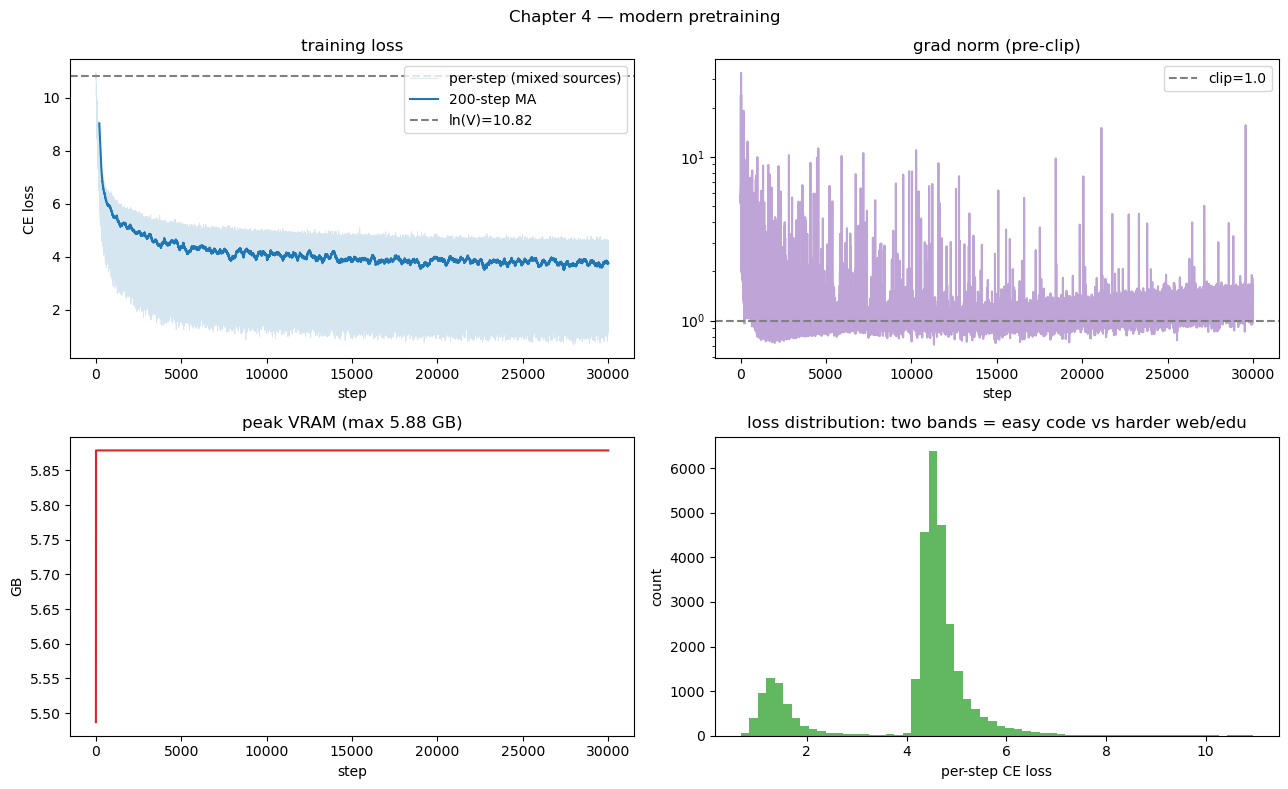

final 200-step MA loss: 3.751   (raw last step: 4.381)


In [23]:
# training dashboard -- loss / grad-norm / VRAM, from the hist dict train_modern returns
import matplotlib.pyplot as plt
import numpy as np

h = hist
s = np.array(h["step"]); loss = np.array(h["loss"])
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

# loss: the raw curve is BIMODAL -- each step is one source; code batches ~1, web/edu ~4-5.
# read the moving average (the weighted-mean trend), not the per-step spikes.
win = min(200, max(10, len(loss) // 20))
ma = np.convolve(loss, np.ones(win) / win, mode="valid")
ax[0, 0].plot(s, loss, alpha=0.18, lw=0.6, label="per-step (mixed sources)")
ax[0, 0].plot(s[win - 1:], ma, color="tab:blue", label=f"{win}-step MA")
ax[0, 0].axhline(math.log(VOCAB_SIZE), ls="--", color="gray", label=f"ln(V)={math.log(VOCAB_SIZE):.2f}")
ax[0, 0].set_title("training loss"); ax[0, 0].set_xlabel("step"); ax[0, 0].set_ylabel("CE loss"); ax[0, 0].legend()

ax[0, 1].semilogy(s, h["grad_norm"], color="tab:purple", alpha=0.6)
ax[0, 1].axhline(1.0, ls="--", color="gray", label="clip=1.0")
ax[0, 1].set_title("grad norm (pre-clip)"); ax[0, 1].set_xlabel("step"); ax[0, 1].legend()

ax[1, 0].plot(s, h["vram_gb"], color="tab:red")
ax[1, 0].set_title(f"peak VRAM (max {max(h['vram_gb']):.2f} GB)")
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("GB")

# the loss histogram makes the mixture's two difficulty bands literally visible
ax[1, 1].hist(loss, bins=60, color="tab:green", alpha=0.75)
ax[1, 1].set_title("loss distribution: two bands = easy code vs harder web/edu")
ax[1, 1].set_xlabel("per-step CE loss"); ax[1, 1].set_ylabel("count")

fig.suptitle("Chapter 4 — modern pretraining"); plt.tight_layout(); plt.show()
print(f"final {win}-step MA loss: {ma[-1]:.3f}   (raw last step: {loss[-1]:.3f})")

In [ ]:
# ---- A/B: old GPT-2-style base.pt  vs  new Llama-style modern.pt, same prompts ----
# Minimal copy of the Ch.3 GPT, just to load base.pt for the comparison.
class _OldBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ln1 = nn.LayerNorm(c.d_model); self.ln2 = nn.LayerNorm(c.d_model)
        self.qkv = nn.Linear(c.d_model, 3*c.d_model); self.out_proj = nn.Linear(c.d_model, c.d_model)
        self.mlp_fc = nn.Linear(c.d_model, 2048); self.mlp_proj = nn.Linear(2048, c.d_model); self.act = nn.GELU()
        self.nh = c.n_heads; self.dk = c.d_model // c.n_heads
    def forward(self, x):
        b, t, _ = x.shape
        q, k, v = self.qkv(self.ln1(x)).chunk(3, -1)
        q = q.view(b, t, self.nh, self.dk).transpose(1, 2); k = k.view(b, t, self.nh, self.dk).transpose(1, 2)
        v = v.view(b, t, self.nh, self.dk).transpose(1, 2)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True).transpose(1, 2).reshape(b, t, -1)
        x = x + self.out_proj(a)
        return x + self.mlp_proj(self.act(self.mlp_fc(self.ln2(x))))

class OldGPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.cfg = c; self.block_size = c.block_size
        self.wte = nn.Embedding(c.vocab_size, c.d_model); self.wpe = nn.Embedding(c.block_size, c.d_model)
        self.blocks = nn.ModuleList([_OldBlock(c) for _ in range(c.n_layers)])
        self.ln_f = nn.LayerNorm(c.d_model)
        self.lm_head = nn.Linear(c.d_model, c.vocab_size, bias=False); self.lm_head.weight = self.wte.weight
    def forward(self, idx, targets=None):
        b, t = idx.shape; pos = torch.arange(t, device=idx.device)
        x = self.wte(idx) + self.wpe(pos)
        for bl in self.blocks: x = bl(x)
        return self.lm_head(self.ln_f(x)), None

@torch.no_grad()
def old_complete(m, prompt, n=40, temperature=0.7, top_k=50):
    m.eval(); ids = torch.tensor([enc.encode_ordinary(prompt)], device=device)
    for _ in range(n):
        lg, _ = m(ids[:, -m.block_size:]); lg = lg[:, -1, :] / temperature
        v, _ = torch.topk(lg, top_k); lg[lg < v[:, [-1]]] = float("-inf")
        ids = torch.cat([ids, torch.multinomial(F.softmax(lg, -1), 1)], 1)
    return enc.decode(ids[0].tolist())

PROMPTS = ["The capital of France is", "Water boils at", "Photosynthesis is the process by which"]
modern = getattr(model, "_orig_mod", model)
if os.path.exists(os.path.join(DATA_DIR, "base.pt")):
    _bk = torch.load(os.path.join(DATA_DIR, "base.pt"), map_location=device, weights_only=False)
    old = OldGPT(_bk["cfg"]).to(device); old.load_state_dict(_bk["model"])
    for p in PROMPTS:
        print("PROMPT:", p)
        print("  OLD (GPT-2, edu-only):  ", repr(old_complete(old, p, 30)))
        print("  NEW (Llama, mixed data):", repr(complete(modern, p, 30)))
        print("-"*80)
else:
    print("base.pt not found -- run 3a first for the side-by-side; showing NEW only:")
    for p in PROMPTS:
        print(p, "->", repr(complete(modern, p, 30)))

## Done — a modern base, and what each change bought

You rebuilt the 2019 GPT-2 model into a 2024 Llama-style decoder and pretrained it on a source mixture. Recap of *why each piece earned its place*:

| change | what it removed | what you gained |
|---|---|---|
| **RoPE** | a learned position table + a length ceiling | relative, **length-extrapolating**, **zero-param** positions |
| **RMSNorm** | mean-centering + the bias term | same stability, **fewer ops**, one less parameter tensor |
| **SwiGLU** | a flat nonlinearity | an input-dependent **gate** → more quality at equal params |
| **GQA** | redundant KV heads | a **4× smaller KV cache** → much faster generation |
| **no biases** | dead parameters | a slightly leaner, steadier net |
| **KV cache** | O(N²) re-computation | **O(N)** generation (and the reason GQA matters) |
| **data mixture** | a single narrow corpus | broader **knowledge coverage** per param |

**The honest caveat:** at ~50M params this is still a tiny model — the A/B should show the new one is *more coherent, more on-topic, and faster to sample*, but it won't suddenly "know everything". The architecture makes every future token count for more; the **data mixture and scale** are what actually fill in knowledge. The biggest remaining lever is still **more tokens** (Chinchilla ~20/param ⇒ ~1B for this size).

### Where this plugs into the project

- **Multilingual:** swap `SOURCES` for per-language slices (FineWeb-2/MADLAD) — the weighted-mixture loader is unchanged. RoPE + a multilingual tokenizer are the only other moving parts.
- **Function-calling / agentic:** SFT this stronger base with the exact 3b machinery (loss masking, chat template), where the "response" is a structured tool call (Glaive/xLAM). A better base = a more reliable tool-caller — the direct fix for the "knows nothing" problem (let it look things up instead of memorizing).
- **Scale:** bump `n_layers`/`d_model` toward ~100–150M now that the architecture is efficient and you have VRAM headroom.